# Use TensorFlow models

This notebook shows how to do inference with trained neural network from Tensorflow.

The first example is a 1D-CNN for wet-dry classification. The model was trained on a dataset from Czechia.

In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import pycomlink as pycml
# importation of the submodule for running the inference 
from pycomlink.processing.tensorflow_utils import run_inference

In [2]:
# suppress tensorflow verbose logging
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
import tensorflow as tf
# print tensorflow, cuda and cudnn versions
print("TensorFlow version:", tf.__version__)
build_info = tf.sysconfig.get_build_info()
print("CUDA version:", build_info.get("cuda_version", "not available (CPU build)"))
print("CUDNN version:", build_info.get("cudnn_version", "not available (CPU build)"))
# print available GPU devices
print("Available GPU devices:", tf.config.list_physical_devices('GPU'))
# warn if no GPU is available or the cudnn version is not 8
if not tf.config.list_physical_devices('GPU'):
    print("Warning: No GPU devices available.")
if build_info.get("cudnn_version") not in (None, "8"):
    print("Warning: CUDNN compatibility is only tested for version 8. Please ensure compatibility.")

TensorFlow version: 2.16.2
CUDA version: not available (CPU build)
CUDNN version: not available (CPU build)
Available GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Load and prepare data

In [3]:
data_path = pycml.io.examples.get_example_data_path()
cmls = xr.open_dataset(data_path + '/example_cml_data.nc')

# select 3 different CMLs to study
cmls = cmls.isel(cml_id = [0, 10, 370])

# Remove outliers, compute tl and interpolate missing values
cmls['tsl'] = cmls.tsl.where(cmls.tsl != 255.0)
cmls['rsl'] = cmls.rsl.where(cmls.rsl != -99.9)
cmls['tl'] = cmls.tsl - cmls.rsl # calculate total loss (previous TRSL)
cmls['tl'] = cmls.tl.interpolate_na(dim='time', method='linear', max_gap='5min')

In [4]:
cmls["tl1"] = cmls["tl"].sel(channel_id = 'channel_1')
cmls["tl2"] = cmls["tl"].sel(channel_id = 'channel_2')

## Run inference 

In [5]:
results = run_inference.wet_dry_1d_cnn(ds=cmls, return_ds=False)

[✅] TensorFlow is using GPU: 1 device(s).
[→] Using cached file: /Users/chwala-c/code/pycomlink/docs/notebooks/model_cnn/CNN__model_v0_cz.json
[→] Using cached file: /Users/chwala-c/code/pycomlink/docs/notebooks/model_cnn/CNN__model_v0_cz.weights.h5


/Users/chwala-c/miniforge3/envs/pycomlink-dev/lib/python3.12/site-packages/keras/src/optimizers/base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


[✓] Model loaded and compiled.
365/365 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


Storing predictions (model): 100%|██████████| 3/3 [00:00<00:00, 2605.70CML/s]


In [6]:
# storing the probabilities  predictions of the cnn model 
cmls["CNN"] = results

## Results

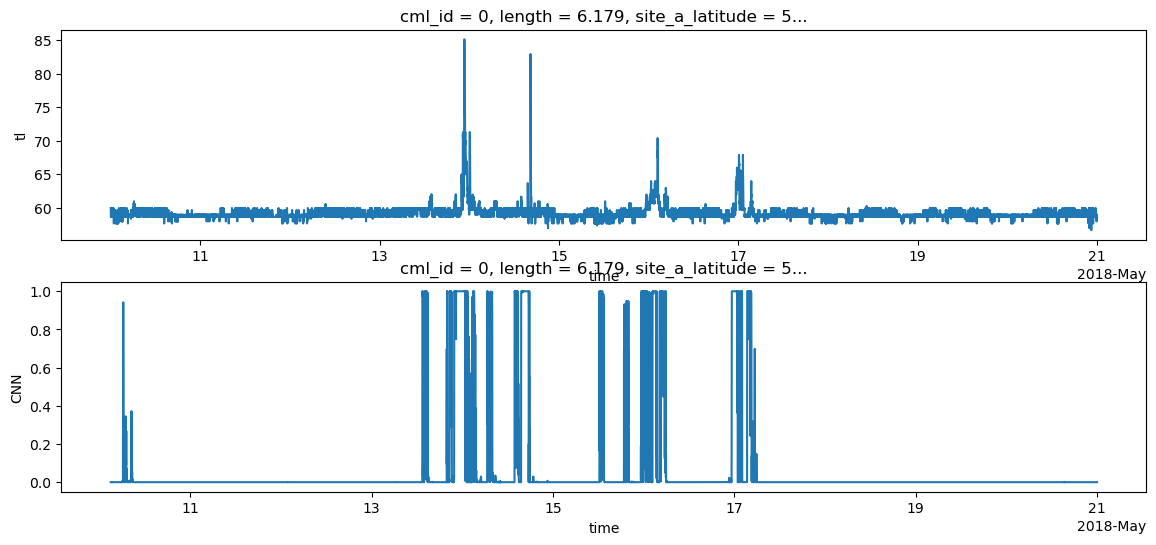

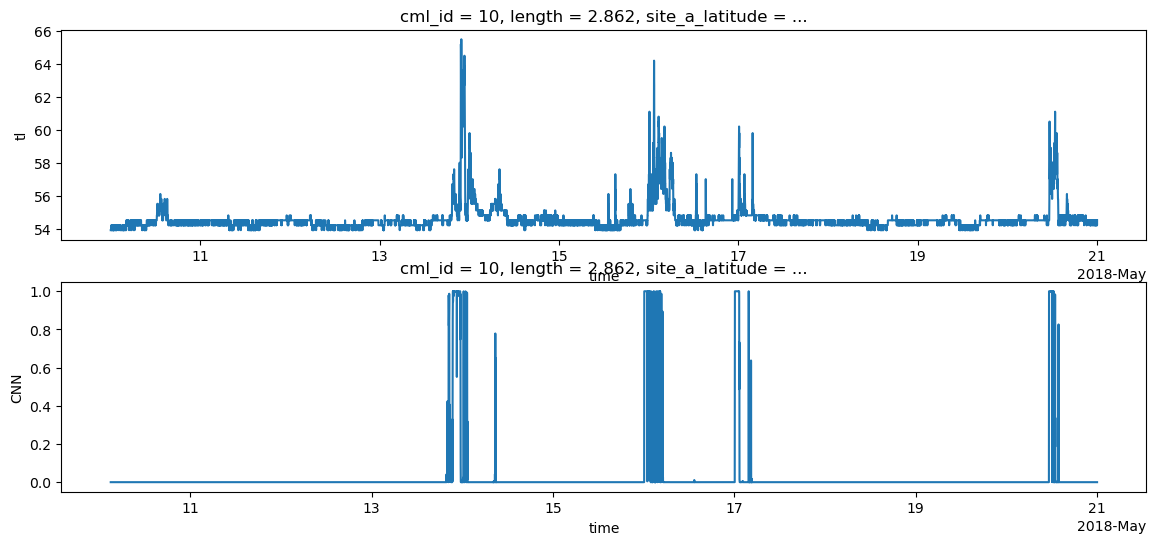

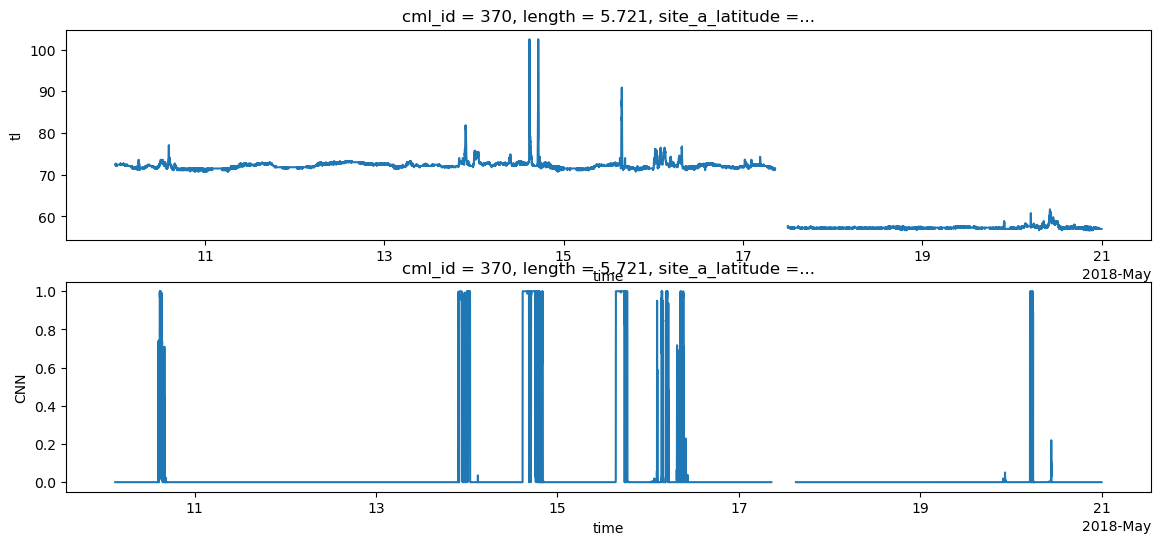

In [7]:
for cml_id in cmls.cml_id.data:
    fig, axs = plt.subplots(2, 1, figsize=(14, 6))
    cmls.tl.sel(cml_id=cml_id).isel(channel_id=0).plot.line(x='time', ax=axs[0])
    cmls.CNN.sel(cml_id=cml_id).plot.line(x='time', ax=axs[1])
    
